In [1]:
import os
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import sys
sys.path.insert(0, '../../src')
import utils

In [2]:
# ── Configure ──────────────────────────────────────────────────────────────────
results_path = '../../outputs/fiducial/sensitivity_results.pt'
figures_dir  = '../../figures/fiducial/sensitivity'
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(figures_dir, exist_ok=True)

res = torch.load(results_path, weights_only=False)

rho_S_range      = np.array(res['rho_S_range'])       # (n_rho,)
theta_star_range = np.array(res['theta_star_range'])   # (n_theta,)
eps_star         = np.array(res['eps_star'])           # (n_rho,)
us_mdp           = np.array(res['us_mdp'])             # (n_rho,)
P_mdp            = np.array(res['P_mdp'])              # (n_rho,)
A_mdp            = np.array(res['A_mdp'])              # (n_rho,)
P_true           = np.array(res['P_true'])             # (n_rho, n_theta)
A_true           = np.array(res['A_true'])             # (n_rho, n_theta)
p_optout_true    = np.array(res['p_optout_true'])      # (n_rho, n_theta)
us_true          = np.array(res['us_true'])            # (n_rho, n_theta)
params           = res['params']

print('Parameters:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nrho_S values  : {rho_S_range.tolist()}')
print(f'theta* values : {theta_star_range.tolist()}')

Parameters:
  rho_A: 240
  T: 3
  n_max: 200
  c0: 48.9
  c1: 0.066
  kappa: 0.05
  theta_b: 0.5
  alpha_0: 1.0
  beta_0: 1.0
  device: cuda
  epsilon_max: 0.9
  tol: 1e-06
  n_episodes: 200000

rho_S values  : [240.0, 500.0, 1000.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 10000.0]
theta* values : [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9]


## 1. Optimal subsidy $\varepsilon^*$ vs $\rho_S$

For each value of the social utility of approval $\rho_S$, Algorithm 1 (divide-and-conquer) finds the subsidy $\varepsilon^*$ that maximises the principal's expected social utility $U^S = \rho_S P_{\text{approval}} - \varepsilon^* A$ under the MDP's Beta-Binomial dynamics.

Single-shot n_max = 500   rho_A = 240.0
   rho_S   rho_S/rho_A    eps*_fid     eps*_ss   n* (eps=0)    n* (eps=eps*_ss)
--------------------------------------------------------------------------------
   240.0         1.000      0.0000      0.0000        87.00               87.00
   500.0         2.083      0.0000      0.0794        87.00              108.00
  1000.0         4.167      0.1079      0.0794        87.00              108.00
  2000.0         8.333      0.1079      0.0794        87.00              108.00
  3000.0        12.500      0.1079      0.0794        87.00              108.00
  4000.0        16.667      0.1079      0.6774        87.00              129.00
  5000.0        20.833      0.2263      0.6774        87.00              129.00
  6000.0        25.000      0.2263      0.6774        87.00              129.00
  7000.0        29.167      0.2263      0.6774        87.00              129.00
  8000.0        33.333      0.3148      0.6774        87.00              129.00

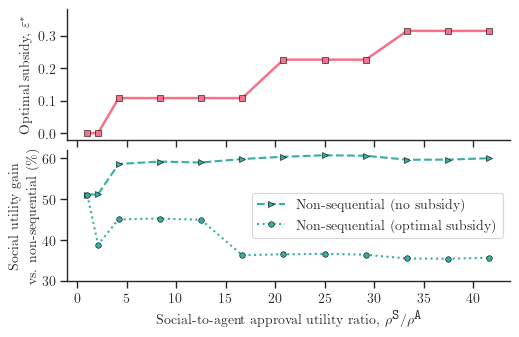

In [3]:
sns.set_theme(context='paper', style='ticks', font_scale=1)
utils.latexify()

width_pt = 750
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_width, fig_height ),
                                      sharex=True,
                                      gridspec_kw={'hspace': 0.08}
                                      )

palette = sns.color_palette('husl', n_colors=4)

rho_A_val = float(params['rho_A'])
x_ratio = rho_S_range / rho_A_val

# ── Top panel: optimal subsidy ──────────────────────────────────────────────
ax_top.plot(x_ratio, eps_star, 's-', color=palette[0],
            linewidth=1.8, markersize=5, label=r'$\varepsilon^*(\rho_S)$ (MDP)',
            markeredgecolor='black', markeredgewidth=0.4)
ax_top.set_ylabel(r'Optimal subsidy, $\varepsilon^*$', fontsize=10)
ax_top.set_ylim(-0.02, max(eps_star) * 1.15 + 0.02)
ax_top.set_yticks([0, 0.1, 0.2, 0.3])
#Set fontsize for ticklabels to 10
ax_top.tick_params(axis='both', labelsize=10)
#ax_top.legend(fontsize=10, loc='upper left')
sns.despine(ax=ax_top)

# ── Load single-shot baseline ────────────────────────────────────────────────
ss_path = '../../outputs/single_shot/baseline/single_shot_baseline.pt'
ss = torch.load(ss_path, weights_only=False)
assert ss['rho_S_range']      == rho_S_range.tolist()
assert ss['theta_star_range'] == theta_star_range.tolist()

us_ss0_    = np.array(ss['us_true_ss0'])
us_ssopt_  = np.array(ss['us_true_ss_epsopt'])
P_ss0_     = np.array(ss['P_true_ss0'])
A_ss0_     = np.array(ss['A_true_ss0'])
P_ssopt_   = np.array(ss['P_true_ss_epsopt'])
A_ssopt_   = np.array(ss['A_true_ss_epsopt'])
eps_ss_opt = np.array(ss['eps_ss_opt'])

theta_fid = 0.65
j_fid = int(np.argmin(np.abs(theta_star_range - theta_fid)))
assert abs(theta_star_range[j_fid] - theta_fid) < 1e-9, \
    f'theta*=0.65 not in theta_star_range: {theta_star_range.tolist()}'

def _pct_gain(num, den):
    return np.where(np.abs(den) > 1e-12, (num - den) / den * 100.0, np.nan)

pct_a_fid = _pct_gain(us_true[:, j_fid], us_ss0_[:,   j_fid])
pct_b_fid = _pct_gain(us_true[:, j_fid], us_ssopt_[:, j_fid])

# Recover n*(0,0) for diagnostics
c0 = float(params['c0']); c1 = float(params['c1'])

def _recover_n_star(A_row, P_row):
    p = P_row[j_fid]; a = A_row[j_fid]
    if p <= 0:
        return float('nan')
    return (a / p - c0) / c1

n_star_ss0   = np.array([_recover_n_star(A_ss0_[i],   P_ss0_[i])   for i in range(len(rho_S_range))])
n_star_ssopt = np.array([_recover_n_star(A_ssopt_[i], P_ssopt_[i]) for i in range(len(rho_S_range))])

n_max_ss = int(ss['params']['n_max'])
print(f"Single-shot n_max = {n_max_ss}   rho_A = {rho_A_val}")
print(f"{'rho_S':>8}  {'rho_S/rho_A':>12}  {'eps*_fid':>10}  {'eps*_ss':>10}  {'n* (eps=0)':>11}  {'n* (eps=eps*_ss)':>18}")
print('-' * 80)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {x_ratio[i]:12.3f}  {eps_star[i]:10.4f}  {eps_ss_opt[i]:10.4f}  "
          f"{n_star_ss0[i]:11.2f}  {n_star_ssopt[i]:18.2f}")

# ── Bottom panel: % utility gain ─────────────────────────────────────────────
ax_bot.plot(x_ratio, pct_a_fid, '>--', color=palette[2],
            linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
            label=r'Non-sequential (no subsidy)')
ax_bot.plot(x_ratio, pct_b_fid, 'o:', color=palette[2],
            linewidth=1.5, markersize=4, markeredgecolor='black', markeredgewidth=0.4,
            label=r'Non-sequential (optimal subsidy)')

ax_bot.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=10)
ax_bot.set_ylabel(
    r'$\begin{array}{c}\textrm{Social utility gain} \\ \textrm{vs. non-sequential}\ (\%)\end{array}$',
    fontsize=10,
    labelpad=12,
    rotation=90,
    va='center'
)
ax_bot.set_ylim(bottom=30)
ax_bot.legend(fontsize=10, loc='best')
sns.despine(ax=ax_bot)

#plt.tight_layout()
plt.show()

fig.subplots_adjust(
    left=0.12,
    right=0.88,   # leave space for colorbar in Code 2
    top=0.95,
    bottom=0.15
)

fig.savefig(os.path.join(figures_dir, 'eps_star_vs_rhoS.pdf'))


In [4]:
# Diagnostic: explain the dip in the red curve at the second rho_S point.
#
# Hypothesis: at rho_S point 2, eps*_fid is still 0, but eps*_ss has just become > 0.
# So U_ssopt jumps above U_ss0 while U_fid is unchanged in the eps direction,
# shrinking the fiducial's *relative* gain over the optimally-subsidized single-shot.
# Meanwhile the green curve (vs eps=0 single-shot) is unaffected because U_ss0 doesn't move.

import pandas as pd

diag = pd.DataFrame({
    'rho_S':            rho_S_range,
    'rho_S/rho_A':      x_ratio,
    'eps*_fid':         eps_star,
    'eps*_ss':          eps_ss_opt,
    'U_fid':            us_true[:, j_fid],
    'U_ss0':            us_ss0_[:,   j_fid],
    'U_ssopt':          us_ssopt_[:, j_fid],
    'gain_vs_ss0_%':    pct_a_fid,
    'gain_vs_ssopt_%':  pct_b_fid,
    'n*_ss(eps=0)':     n_star_ss0,
    'n*_ss(eps=eps*)':  n_star_ssopt,
})
print(diag.to_string(index=False, float_format=lambda x: f'{x:10.4f}'))

print('\nFocused check on the first few rho_S points:')
print('  expect U_ssopt-U_ss0 ~ 0 at point 1, then jump > 0 at point 2 ⇒ red curve dip')
for i in range(min(4, len(rho_S_range))):
    d = us_ssopt_[i, j_fid] - us_ss0_[i, j_fid]
    print(f"  rho_S={rho_S_range[i]:7.1f}  eps*_fid={eps_star[i]:.4f}  "
          f"eps*_ss={eps_ss_opt[i]:.4f}  U_ssopt-U_ss0={d:+.4f}  "
          f"n*_ss0={n_star_ss0[i]:6.1f} -> n*_ssopt={n_star_ssopt[i]:6.1f}")


     rho_S  rho_S/rho_A   eps*_fid    eps*_ss      U_fid      U_ss0    U_ssopt  gain_vs_ss0_%  gain_vs_ssopt_%  n*_ss(eps=0)  n*_ss(eps=eps*)
  240.0000       1.0000     0.0000     0.0000   184.8012   122.3112   122.3592        51.0910          51.0317       87.0000          87.0000
  500.0000       2.0833     0.0000     0.0794   385.2550   254.8150   277.4451        51.1901          38.8581       87.0000         108.0000
 1000.0000       4.1667     0.1079     0.0794   808.4220   509.6300   557.3801        58.6292          45.0396       87.0000         108.0000
 2000.0000       8.3333     0.1079     0.0794  1622.8158  1019.2600  1117.2501        59.2151          45.2509       87.0000         108.0000
 3000.0000      12.5000     0.1079     0.0794  2430.7836  1528.8900  1677.1201        58.9901          44.9380       87.0000         108.0000
 4000.0000      16.6667     0.1079     0.6774  3258.4457  2038.5200  2391.3417        59.8437          36.2601       87.0000         129.0000
 5000.

## 2. MDP social utility $U^S_{\text{MDP}}$ vs $\rho_S$

Social utility under the MDP (Beta-Binomial) dynamics at the optimal subsidy.

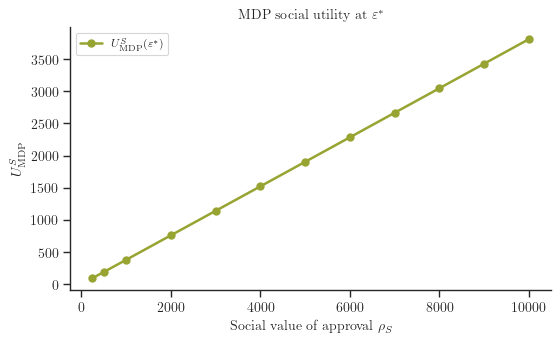

In [5]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(rho_S_range, us_mdp, 'o-', color=palette[1],
        linewidth=1.8, markersize=5, label=r'$U^S_{\mathrm{MDP}}(\varepsilon^*)$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'$U^S_{\mathrm{MDP}}$')
ax.set_title(r'MDP social utility at $\varepsilon^*$')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_mdp_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 3. True social utility $U^S_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

For each $\theta^*$, the true social utility at the MDP-optimal subsidy $\varepsilon^*(\rho_S)$ is
$$
U^S_{\text{true}}(\varepsilon^*;\pi^*,\theta^*) = \rho_S\,P_{\text{true}}(\theta^*) - \varepsilon^* A_{\text{true}}(\theta^*)
$$
estimated via Monte Carlo under Binomial$(n, \theta^*)$ rollouts.

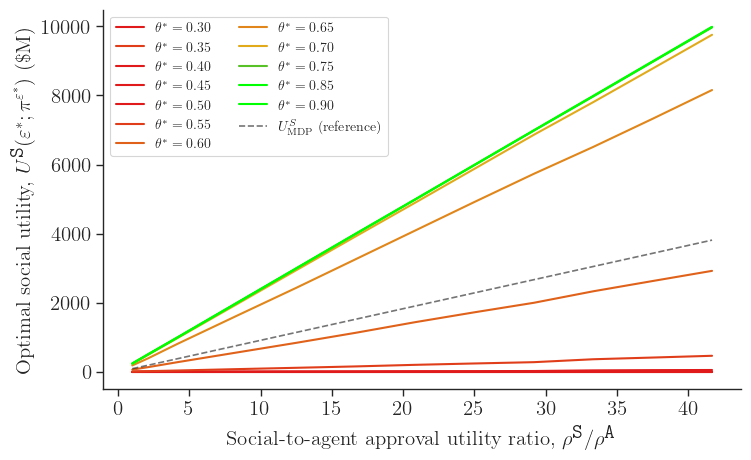

In [6]:
width_pt = 1000
fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.55)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# One color per theta* value, red -> green (edit freely)
line_colors = [
    '#e01a1a',  # 0.30
    '#e03e1a',  # 0.35
    '#e01a1a',  # 0.40
    '#e01a1a',  # 0.45
    '#e01a1a',  # 0.50
    '#e03e1a',  # 0.55
    '#e0621a',  # 0.60
    '#e0861a',  # 0.65
    '#e0aa1a',  # 0.70
    "#58c128",  # 0.75
    '#00ff00',  # 0.85
    "#00ff00",  # 0.90
]

for j, theta_star in enumerate(theta_star_range):
    ax.plot(x_ratio, us_true[:, j],
            color=line_colors[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# Overlay MDP social utility for comparison
ax.plot(x_ratio, us_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$U^S_{\mathrm{MDP}}$ (reference)')

ax.legend(fontsize=10, ncol=2, loc='best')

ax.set_ylabel(r'Optimal social utility, $U^{\texttt{S}}(\varepsilon^*;\pi^{\varepsilon^*})$ (\$M)', fontsize=15)
ax.set_xlabel(r'Social-to-agent approval utility ratio, $\rho^{\texttt{S}} / \rho^{\texttt{A}}$', fontsize=15)
ax.set_xticks(range(0, 41, 5))
ax.tick_params(axis='both', labelsize=15)

sns.despine()
plt.tight_layout()
plt.show()


fig.savefig(os.path.join(figures_dir, 'us_true_vs_rhoS.pdf'), bbox_inches='tight')


## 4. True opt-out probability (before approval) vs $\rho_S$ (one curve per $\theta^*$)

$P_{\theta^*}(\text{agent opts out before approval})$ under the MDP-optimal policy at $\varepsilon^*(\rho_S)$, evaluated via Monte Carlo rollouts.

NameError: name 'colors_theta' is not defined

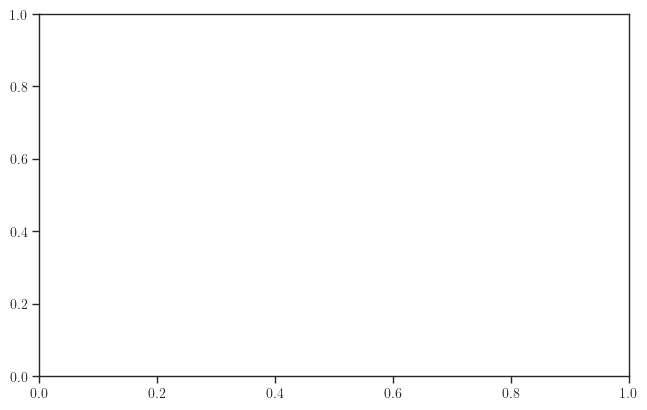

In [8]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, p_optout_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Prob opt-out before approval')
ax.set_title(r'True opt-out probability vs $\rho_S$ for each theta star')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'p_optout_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 5. True approval probability $P_{\text{true}}$ vs $\rho_S$ (one curve per $\theta^*$)

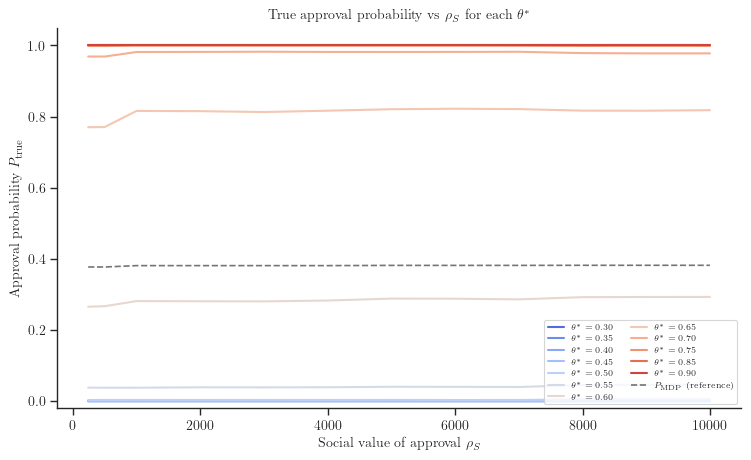

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for j, theta_star in enumerate(theta_star_range):
    ax.plot(rho_S_range, P_true[:, j],
            color=colors_theta[j], linewidth=1.5,
            label=fr'$\theta^*={theta_star:.2f}$')

# MDP approval probability for reference
ax.plot(rho_S_range, P_mdp, 'k--', linewidth=1.2, alpha=0.6,
        label=r'$P_{\mathrm{MDP}}$ (reference)')

ax.set_xlabel(r'Social value of approval $\rho_S$')
ax.set_ylabel(r'Approval probability $P_{\mathrm{true}}$')
ax.set_title(r'True approval probability vs $\rho_S$ for each $\theta^*$')
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=6, ncol=2, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'P_true_vs_rhoS.png'), dpi=200, bbox_inches='tight')

## 6. Summary table

In [ ]:
print(f"{'rho_S':>8}  {'eps*':>8}  {'U^S_mdp':>10}  {'P_mdp':>7}  {'A_mdp':>7}")
print('-' * 50)
for i, rho_S in enumerate(rho_S_range):
    print(f"{rho_S:8.1f}  {eps_star[i]:8.4f}  {us_mdp[i]:10.2f}  "
          f"{P_mdp[i]:7.4f}  {A_mdp[i]:7.2f}")

   rho_S      eps*     U^S_mdp    P_mdp    A_mdp
--------------------------------------------------
   240.0    0.0000       90.53   0.3772    22.31
   500.0    0.0000      188.60   0.3772    22.31
  1000.0    0.1079      378.57   0.3810    22.84
  2000.0    0.1079      759.60   0.3810    22.84
  3000.0    0.1079     1140.63   0.3810    22.84
  4000.0    0.1079     1521.66   0.3810    22.84
  5000.0    0.2263     1903.17   0.3817    22.99
  6000.0    0.2263     2284.85   0.3817    22.99
  7000.0    0.2263     2666.53   0.3817    22.99
  8000.0    0.3148     3048.23   0.3819    23.21
  9000.0    0.3148     3430.18   0.3819    23.21
 10000.0    0.3148     3812.12   0.3819    23.21


## 7. Decomposition vs single-shot baseline ($T=0$, $n_{\max}=500$)

Two single-shot baselines are computed in `single_shot_baseline.py`:

- **(a)** $\varepsilon = 0$ — neither subsidies nor sequentiality are used by the principal.
- **(b)** $\varepsilon = \varepsilon^*_{\text{fid}}(\rho_S)$ — the fiducial-optimal subsidy is used, but only one block of trials is allowed.

For each $\theta^*$, we plot
$\Delta U^S_{\text{true}}(\rho_S;\theta^*) = U^S_{\text{true,fid}} - U^S_{\text{true,ss}}$.
Curve (a) measures the *joint* effect of multiple sequential tests + optimal subsidy; curve (b) isolates the effect of sequentiality alone (subsidy held fixed).

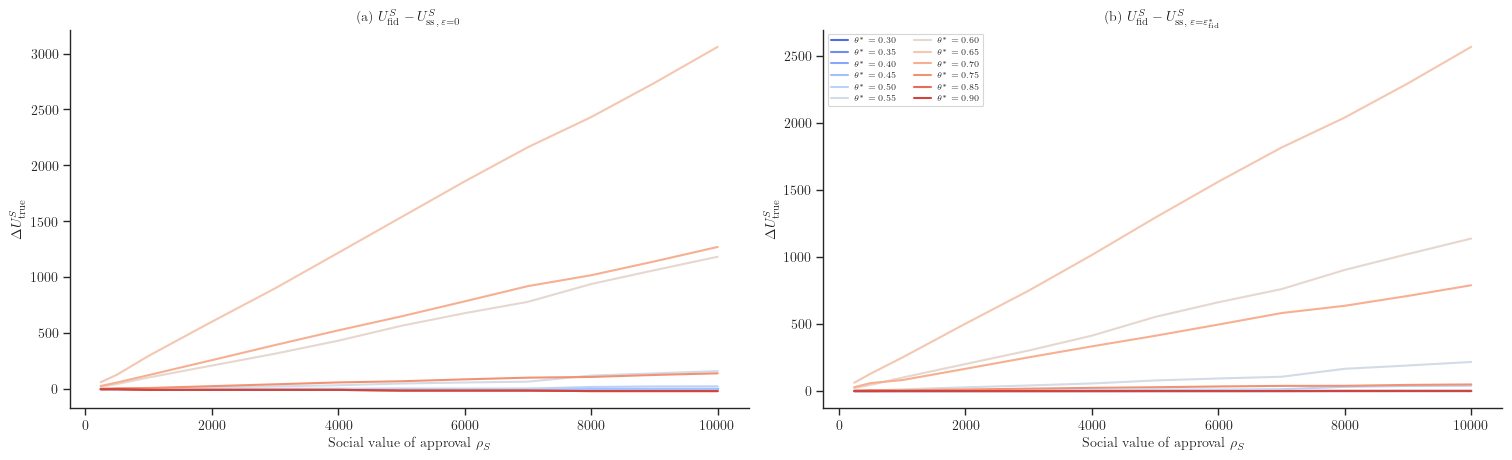

In [ ]:
ss_path = '../../outputs/single_shot/baseline/single_shot_baseline.pt'
ss = torch.load(ss_path, weights_only=False)

assert ss['rho_S_range']      == rho_S_range.tolist()
assert ss['theta_star_range'] == theta_star_range.tolist()

us_ss0    = np.array(ss['us_true_ss0'])         # (n_rho, n_theta)  eps = 0
us_sseps  = np.array(ss['us_true_ss_epsfid'])   # (n_rho, n_theta)  eps = eps*_fid

delta_a = us_true - us_ss0     # joint effect: sequentiality + subsidy
delta_b = us_true - us_sseps   # sequentiality only (subsidy fixed)

fig, axes = plt.subplots(1, 2, figsize=(fig_width * 2.0, fig_height), sharey=False)

for ax, delta, title in [
    (axes[0], delta_a, r'(a) $U^S_{\mathrm{fid}} - U^S_{\mathrm{ss},\,\varepsilon=0}$'),
    (axes[1], delta_b, r'(b) $U^S_{\mathrm{fid}} - U^S_{\mathrm{ss},\,\varepsilon=\varepsilon^*_{\mathrm{fid}}}$'),
]:
    for j, theta_star in enumerate(theta_star_range):
        ax.plot(rho_S_range, delta[:, j],
                color=colors_theta[j], linewidth=1.5,
                label=fr'$\theta^*={theta_star:.2f}$')
    ax.set_xlabel(r'Social value of approval $\rho_S$')
    ax.set_ylabel(r'$\Delta U^S_{\mathrm{true}}$')
    ax.set_title(title)
    sns.despine(ax=ax)

axes[1].legend(fontsize=6, ncol=2, loc='best')
plt.tight_layout()
plt.show()

fig.savefig(os.path.join(figures_dir, 'us_true_decomposition_vs_rhoS.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(figures_dir, 'us_true_decomposition_vs_rhoS.png'), dpi=200, bbox_inches='tight')